# Bank Loan Approval Prediction Using Machine Learning

**Week 4 – Major Project (Capstone Project)**

### Objective
Build a complete machine learning pipeline to predict whether a loan application will be approved (`Y`) or rejected (`N`).

### Workflow
1. Load and understand the dataset
2. Exploratory Data Analysis (EDA)
3. Data cleaning and missing-value treatment
4. Feature engineering and categorical encoding
5. Train/test split
6. Train multiple classification models
7. Evaluate using accuracy, precision, recall, F1-score and ROC-AUC
8. Visualize the confusion matrix and ROC curve
9. Analyze feature importance
10. Save the best model for future predictions


In [1]:
# Install dependencies if needed (run this cell in Jupyter/Colab)
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)
from xgboost import XGBClassifier

RANDOM_STATE = 42

# Works from the project root or from notebooks/
possible_paths = [
    Path("../data/Loan Prediction.csv"),
    Path("data/Loan Prediction.csv"),
    Path("/mnt/data/Bank-Loan-Approval-Prediction/data/Loan Prediction.csv")
]
data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Loan Prediction.csv not found. Put it in the project's data/ folder.")

df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["Loan_Status"].value_counts())


Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data types:


,dtype
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64



Missing values:


,missing_values
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14



Duplicate rows: 0

Target distribution:


Loan_Status
Y    422
N    192
Name: count, dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


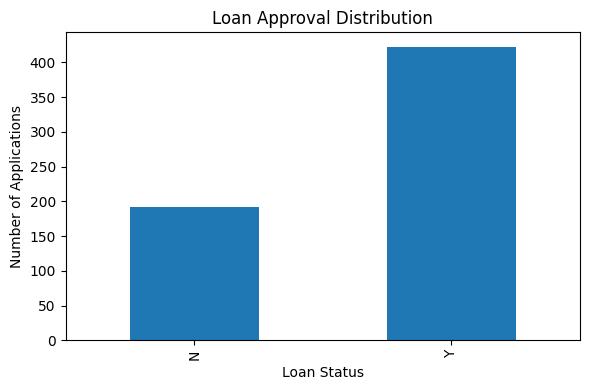

In [4]:
# Basic statistics
display(df.describe(include="all").T)

# Target distribution
plt.figure(figsize=(6, 4))
df["Loan_Status"].value_counts().sort_index().plot(kind="bar")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.tight_layout()
plt.savefig("../visualizations/loan_status_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


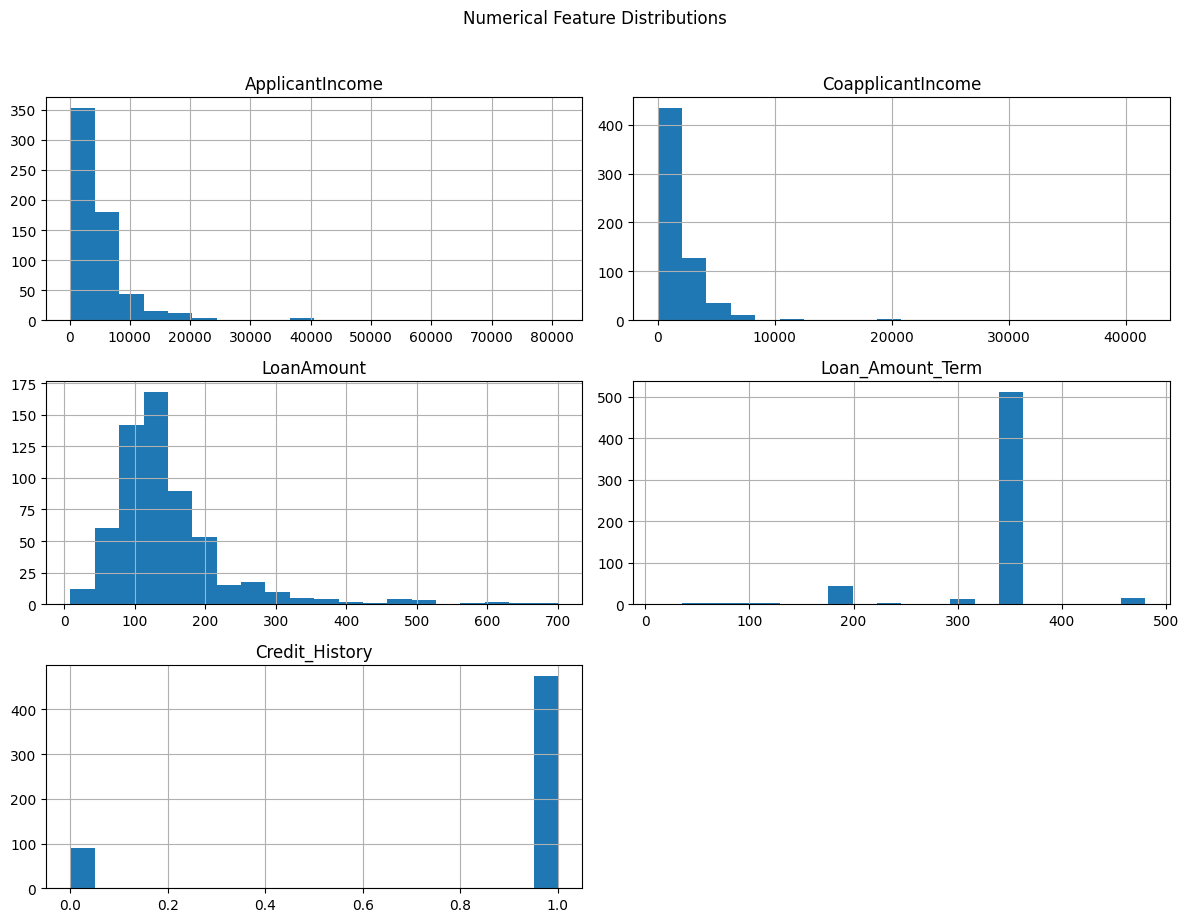

In [5]:
# Numerical distributions
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_cols].hist(figsize=(12, 9), bins=20)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig("../visualizations/numerical_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


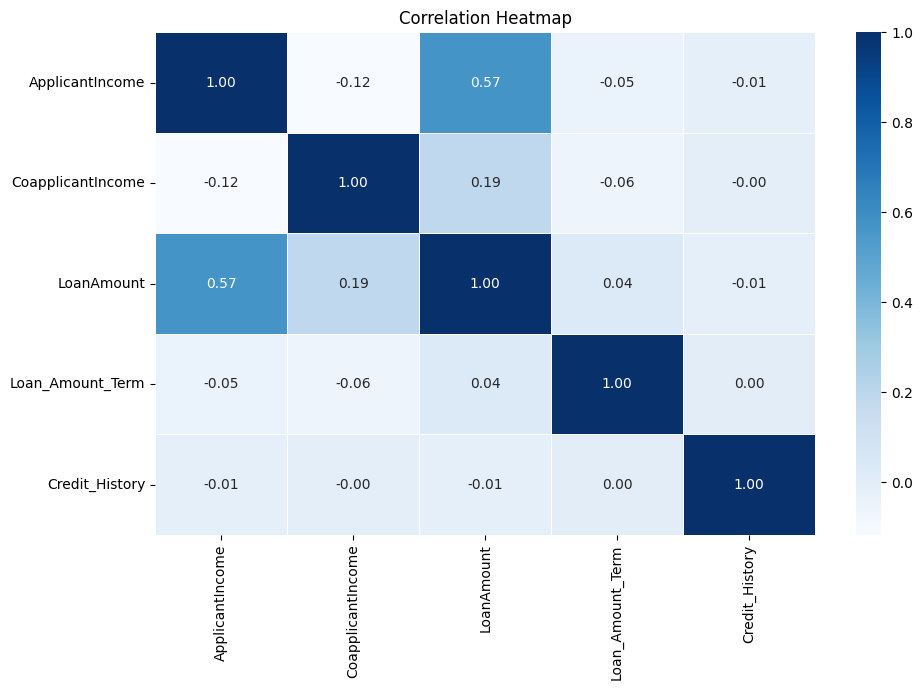

In [6]:
# Correlation heatmap for numeric variables
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../visualizations/correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


## Data Cleaning & Feature Engineering

- `Loan_ID` is an identifier and is removed because it has no meaningful predictive relationship.
- Missing numeric values are imputed with the median.
- Missing categorical values are imputed with the most frequent category.
- `Dependents = 3+` is converted to a numeric value of `3`.
- Categorical variables are one-hot encoded.
- Numeric variables are standardized for models such as Logistic Regression.
- All preprocessing is placed inside a scikit-learn pipeline to avoid data leakage.


In [7]:
# Copy data before preprocessing
data = df.copy()

# Convert Dependents from strings to numeric
data["Dependents"] = data["Dependents"].replace("3+", "3")
data["Dependents"] = pd.to_numeric(data["Dependents"], errors="coerce")

# Remove identifier
data = data.drop(columns=["Loan_ID"])

# Convert target to binary: Y=1, N=0
data["Loan_Status"] = data["Loan_Status"].map({"Y": 1, "N": 0})

X = data.drop(columns=["Loan_Status"])
y = data["Loan_Status"]

print("Features:", X.columns.tolist())
print("Target values:", sorted(y.unique()))


Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']
Target values: [np.int64(0), np.int64(1)]


In [8]:
# Train/test split with stratification to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Training samples: 491
Testing samples: 123
Numeric features: ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical features: ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']


## Model Training

Four models are used:

1. Logistic Regression – baseline linear classifier
2. Decision Tree – interpretable nonlinear model
3. Random Forest – ensemble of decision trees
4. XGBoost – gradient-boosted tree ensemble


In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_split=10, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, max_depth=8, min_samples_split=5,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

results = []
fitted_models = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-Score": "{:.3f}",
    "ROC-AUC": "{:.3f}"
}))


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.862,0.840,0.988,0.908,0.848
1,Random Forest,0.813,0.837,0.906,0.870,0.801
2,XGBoost,0.813,0.844,0.894,0.869,0.777
3,Decision Tree,0.829,0.833,0.941,0.884,0.751


In [10]:
# Select the model with the highest ROC-AUC on the held-out test set
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("Selected model:", best_model_name)

best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(
    y_test, best_pred,
    target_names=["Rejected (N)", "Approved (Y)"],
    digits=3
))


Selected model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

Rejected (N)      0.957     0.579     0.721        38
Approved (Y)      0.840     0.988     0.908        85

    accuracy                          0.862       123
   macro avg      0.898     0.784     0.815       123
weighted avg      0.876     0.862     0.850       123



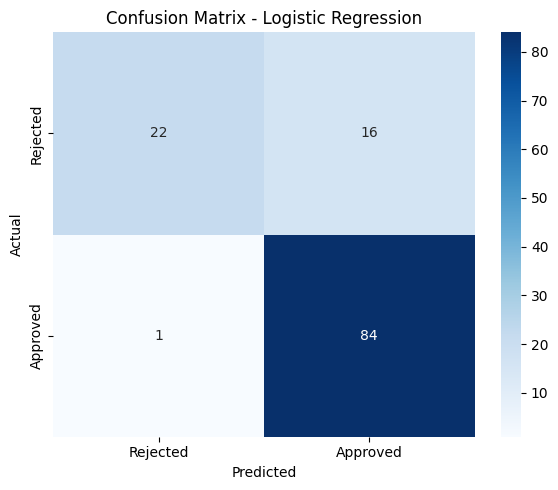

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../visualizations/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


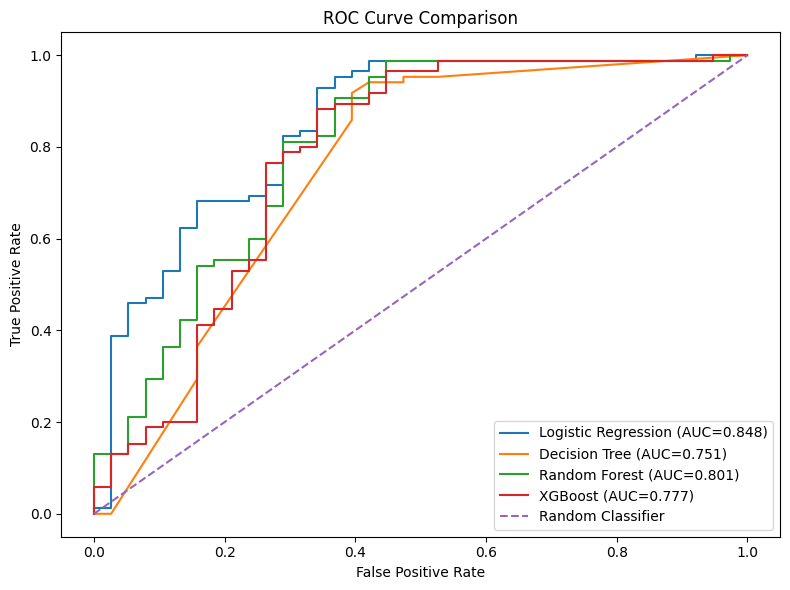

In [12]:
# ROC curves for all models
plt.figure(figsize=(8, 6))

for name, pipeline in fitted_models.items():
    prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/roc_curve_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


In [13]:
# Feature importance for tree-based best model, if available
model_step = best_model.named_steps["model"]
prep_step = best_model.named_steps["preprocessor"]

feature_names = prep_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, y="Feature", x="Importance")
    plt.title(f"Top Features - {best_model_name}")
    plt.tight_layout()
    plt.savefig("../visualizations/feature_importance.png", dpi=200, bbox_inches="tight")
    plt.show()
    display(importance_df)
else:
    print("Feature importance is not directly available for this model.")


Feature importance is not directly available for this model.


## Example Prediction

The trained pipeline can accept a new loan application in the same raw format as the original dataset. Preprocessing is automatically applied before prediction.


In [14]:
# Example application
new_application = pd.DataFrame([{
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "1",
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 5000,
    "CoapplicantIncome": 1500,
    "LoanAmount": 150,
    "Loan_Amount_Term": 360,
    "Credit_History": 1.0,
    "Property_Area": "Urban"
}])

prediction = best_model.predict(new_application)[0]
probability = best_model.predict_proba(new_application)[0, 1]

print("Prediction:", "Approved (Y)" if prediction == 1 else "Rejected (N)")
print(f"Approval probability: {probability:.2%}")


Prediction: Approved (Y)
Approval probability: 80.69%


In [15]:
# Save model and evaluation results
model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

joblib.dump(best_model, model_dir / "loan_approval_model.pkl")
results_df.to_csv(model_dir / "model_comparison.csv", index=False)

print("Saved:")
print(model_dir / "loan_approval_model.pkl")
print(model_dir / "model_comparison.csv")


Saved:
../models/loan_approval_model.pkl
../models/model_comparison.csv


## Conclusion

This project demonstrates an end-to-end supervised machine learning pipeline for loan approval prediction. The workflow covers data exploration, missing-value handling, categorical encoding, feature scaling, multiple classification algorithms, evaluation using several classification metrics, confusion-matrix and ROC visualizations, feature analysis, and model persistence.

**Important:** Model performance depends on the train/test split and dataset characteristics. This project is an educational prediction system and should not be used as the sole basis for real-world lending decisions.
